<a href="https://colab.research.google.com/github/salikb7/Machine-Learning-on-Big-Data-/blob/main/week8_BankNote_Authentication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Salik Ram Bhandari

id= 3260364

Perceptron Learning Algorithm: MSc Guided Lab
Dr Mustansar Ali Ghazanfar
From linear decision boundaries to a manual learning algorithm

This notebook develops a perceptron classifier from first principles and uses PySpark for data preparation and NumPy for the transparent, step-by-step learning algorithm.

Learning outcomes
By the end of the lab, students should be able to:

explain how feature scale affects geometry and perceptron learning;
prevent preprocessing leakage by fitting the scaler only on training data;
implement the perceptron prediction and update rules;
interpret the learning curve, weights, bias and decision scores;
evaluate a binary classifier using a confusion matrix and standard metrics;
explain why a perceptron may fail to converge;
distinguish a local teaching implementation from a distributed big-data implementation.
Important: The UCI dataset records the target as class 0 or class 1.
This notebook does not assign unsupported semantic names such as “authentic” or “forged” to those numeric labels.

Lab structure
Environment setup
Data loading and inspection
Exploratory visualisation
Train–test split and leakage-free scaling
Manual perceptron implementation
Training diagnostics
Test-set evaluation
Two-dimensional geometric visualisation
MSc extension activities

# ==========================================================
# 1. Install PySpark
# ==========================================================
# Run this cell once in Google Colab or a fresh environment.

In [27]:
!pip install -q pyspark

# ==========================================================
# 2. Import required libraries
# ==========================================================


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, isnan
from pyspark.ml.feature import VectorAssembler, StandardScaler

from sklearn.decomposition import PCA
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


# ==========================================================
# 3. Create a Spark session
# ==========================================================


In [29]:
spark = (
    SparkSession.builder
    .appName("Perceptron_MSc_Guided_Lab")
    .getOrCreate()
)

print("Spark version:", spark.version)

Spark version: 4.0.3


1. Load the banknote dataset
The dataset contains four continuous input features and one binary class label.

The four features are derived from wavelet-transformed images:

Variance
Skewness
Curtosis
Entropy
The target is coded as 0 or 1.


# ==========================================================
# 4. Load the dataset
# ==========================================================


In [59]:
# Using the provided BankNote_Authentication.csv file
pdf = pd.read_csv('/content/BankNote_Authentication.csv')

columns = [
    "variance",
    "skewness",
    "curtosis",
    "entropy",
    "class",
]
# The column names in the provided CSV are already lowercase
pdf.columns = columns

# Keep an explicit integer target.
pdf["class"] = pdf["class"].astype(int)

df = spark.createDataFrame(pdf)

print("Dataset loaded successfully.")
df.show(5)

Dataset loaded successfully.
+--------+--------+--------+--------+-----+
|variance|skewness|curtosis| entropy|class|
+--------+--------+--------+--------+-----+
|  3.6216|  8.6661| -2.8073|-0.44699|    0|
|  4.5459|  8.1674| -2.4586| -1.4621|    0|
|   3.866| -2.6383|  1.9242| 0.10645|    0|
|  3.4566|  9.5228| -4.0112| -3.5944|    0|
| 0.32924| -4.4552|  4.5718| -0.9888|    0|
+--------+--------+--------+--------+-----+
only showing top 5 rows


# ==========================================================
# 5. Inspect the dataset
# ==========================================================


In [60]:
print("Schema")
df.printSchema()

row_count = df.count()
column_count = len(df.columns)

print("\nDimensions")
print("Rows   :", row_count)
print("Columns:", column_count)

print("\nSummary statistics")
df.describe().show()

print("\nClass distribution")
df.groupBy("class").count().orderBy("class").show()

print("\nMissing values")
df.select([
    count(
        when(col(c).isNull() | isnan(c), c)
    ).alias(c)
    for c in df.columns
]).show()

Schema
root
 |-- variance: double (nullable = true)
 |-- skewness: double (nullable = true)
 |-- curtosis: double (nullable = true)
 |-- entropy: double (nullable = true)
 |-- class: long (nullable = true)


Dimensions
Rows   : 1372
Columns: 5

Summary statistics
+-------+------------------+------------------+------------------+-------------------+-------------------+
|summary|          variance|          skewness|          curtosis|            entropy|              class|
+-------+------------------+------------------+------------------+-------------------+-------------------+
|  count|              1372|              1372|              1372|               1372|               1372|
|   mean|0.4337352570699717|1.9223531206393598|1.3976271172667647|-1.1916565200437317| 0.4446064139941691|
| stddev| 2.842762586278561| 5.869046743695514| 4.310030090106595| 2.1010131373596095|0.49710327012566086|
|    min|           -7.0421|          -13.7731|           -5.2861|            -8.5482|        

2. Exploratory visualisation
These plots are descriptive. They help us examine:

class balance;
feature distributions;
pairwise separation;
correlation among features.
They do not prove that the complete four-dimensional dataset is linearly separable.


# ==========================================================
# 6. Visual 1: Class distribution
# ==========================================================


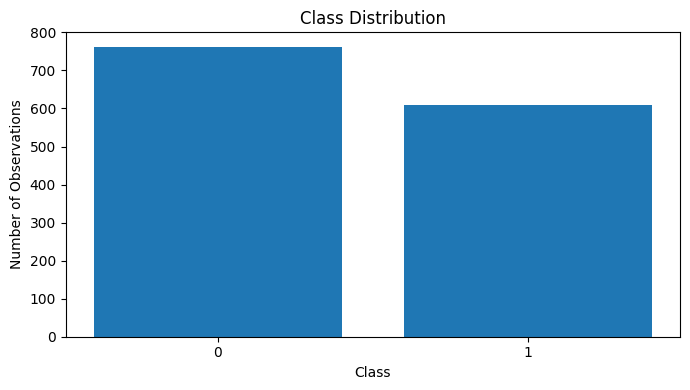

class
0    762
1    610
Name: count, dtype: int64


In [61]:
class_counts = pdf["class"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

print(class_counts)

# ==========================================================
# 7. Visuals 2–5: Feature distributions by class
# ==========================================================
# A separate figure is produced for each feature.

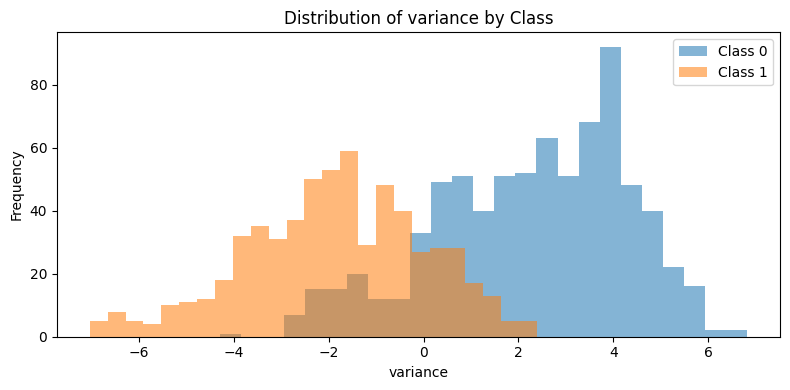

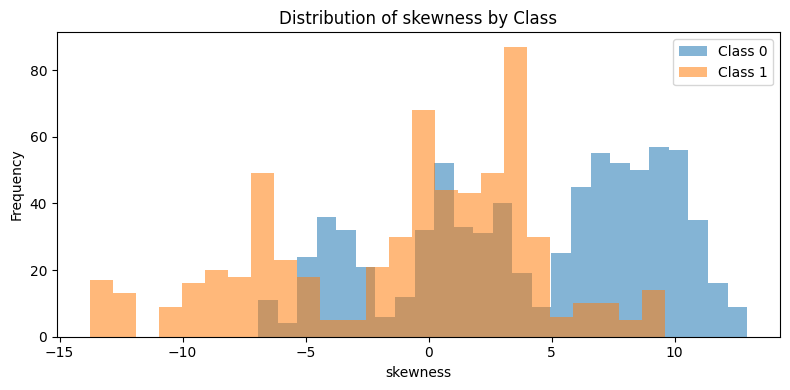

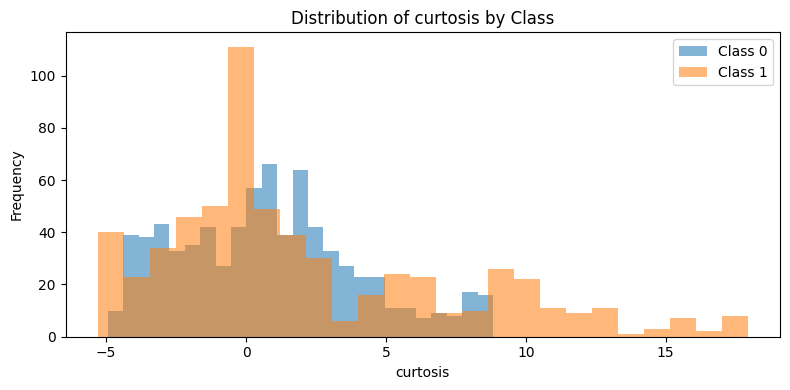

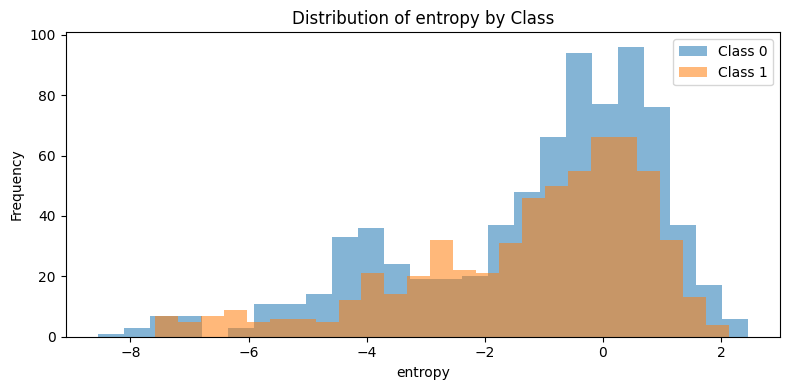

In [62]:
feature_columns = [
    "variance",
    "skewness",
    "curtosis",
    "entropy",
]

for feature in feature_columns:
    plt.figure(figsize=(8, 4))

    for class_value in sorted(pdf["class"].unique()):
        values = pdf.loc[pdf["class"] == class_value, feature]
        plt.hist(
            values,
            bins=25,
            alpha=0.55,
            label=f"Class {class_value}",
        )

    plt.title(f"Distribution of {feature} by Class")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==========================================================
# 8. Visual 6: Two-feature scatter plot
# ==========================================================


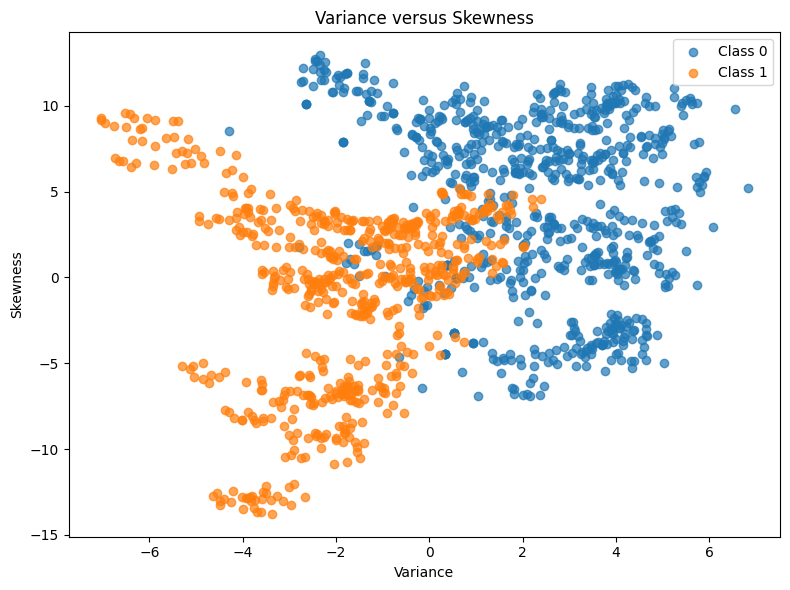

This two-dimensional view may hide overlap or separation that exists in the other features.


In [63]:
plt.figure(figsize=(8, 6))

for class_value in sorted(pdf["class"].unique()):
    subset = pdf[pdf["class"] == class_value]

    plt.scatter(
        subset["variance"],
        subset["skewness"],
        label=f"Class {class_value}",
        alpha=0.7,
    )

plt.title("Variance versus Skewness")
plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "This two-dimensional view may hide overlap or separation "
    "that exists in the other features."
)

# ==========================================================
# 9. Visual 7: Correlation matrix
# ==========================================================


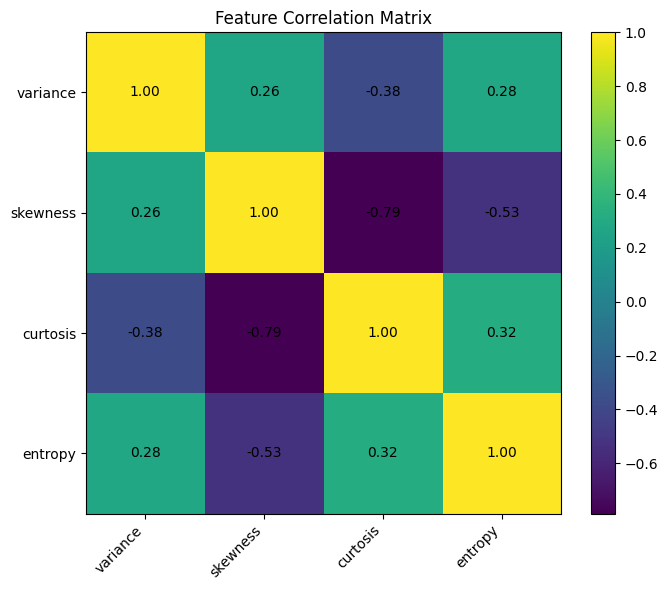

In [64]:
correlation_matrix = pdf[feature_columns].corr()

plt.figure(figsize=(7, 6))
image = plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(image)

tick_positions = np.arange(len(feature_columns))
plt.xticks(tick_positions, feature_columns, rotation=45, ha="right")
plt.yticks(tick_positions, feature_columns)

for row in range(correlation_matrix.shape[0]):
    for column in range(correlation_matrix.shape[1]):
        plt.text(
            column,
            row,
            f"{correlation_matrix.iloc[row, column]:.2f}",
            ha="center",
            va="center",
        )

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

3. Assemble, split and scale the features
Correct preprocessing order
The correct order is:

assemble the raw feature vector;
split the data into training and test sets;
fit the scaler only on the training data;
use the fitted scaler to transform both sets.
Fitting the scaler before the split would allow information from the test set to influence training. This is data leakage.


# ==========================================================
# 10. Assemble the raw feature vector
# ==========================================================


In [65]:
assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features",
)

assembled_data = assembler.transform(df)

assembled_data.select("features", "class").show(5, truncate=False)

+--------------------------------+-----+
|features                        |class|
+--------------------------------+-----+
|[3.6216,8.6661,-2.8073,-0.44699]|0    |
|[4.5459,8.1674,-2.4586,-1.4621] |0    |
|[3.866,-2.6383,1.9242,0.10645]  |0    |
|[3.4566,9.5228,-4.0112,-3.5944] |0    |
|[0.32924,-4.4552,4.5718,-0.9888]|0    |
+--------------------------------+-----+
only showing top 5 rows


# ==========================================================
# 11. Split BEFORE fitting the scaler
# ==========================================================


In [67]:
train_raw, test_raw = assembled_data.randomSplit(
    [0.80, 0.20],
    seed=RANDOM_STATE,
)

# Cache because these frames are used repeatedly.
train_raw = train_raw.cache()
test_raw = test_raw.cache()

train_count = train_raw.count()
test_count = test_raw.count()

print("Training observations:", train_count)
print("Test observations    :", test_count)
print("Total                :", train_count + test_count)

Training observations: 1117
Test observations    : 255
Total                : 1372


# ==========================================================
# 12. Fit the scaler only on the training data
# ==========================================================


In [68]:
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaledFeatures",
    withMean=True,
    withStd=True,
)

scaler_model = scaler.fit(train_raw)

train_df = scaler_model.transform(train_raw)
test_df = scaler_model.transform(test_raw)

print("Training data after scaling")
train_df.select("scaledFeatures", "class").show(5, truncate=False)

Training data after scaling
+---------------------------------------------------------------------------------+-----+
|scaledFeatures                                                                   |class|
+---------------------------------------------------------------------------------+-----+
|[-1.679416310648687,1.1143482574582444,0.4046039774061341,0.12607497976257642]   |0    |
|[-1.153782605222557,-0.036374792252223606,1.253100395808368,0.3735422528955864]  |0    |
|[-1.1212492377070553,1.7408530289672768,-0.17000244515275867,-3.5252729627191273]|0    |
|[-1.1033119215633735,1.3894989244556806,-0.6384464817132329,-2.052880005742022]  |0    |
|[-1.1033119215633735,1.3894989244556806,-0.6384464817132329,-2.052880005742022]  |0    |
+---------------------------------------------------------------------------------+-----+
only showing top 5 rows


# ==========================================================
# 13. Inspect the learned scaling parameters
# ==========================================================


In [70]:
scaling_parameters = pd.DataFrame({
    "Feature": feature_columns,
    "Training Mean": scaler_model.mean.toArray(),
    "Training Standard Deviation": scaler_model.std.toArray(),
})

print(scaling_parameters.to_string(index=False))
print("Why scaling matters\nChanging a feature from millimetres to metres does not change the underlying classification problem. However, it changes the feature's numerical scale.\n\nThe perceptron can relearn an equivalent boundary, but:\n\nits numerical weights will change;\nits updates will follow a different path;\ntraining may be less stable when feature scales differ substantially.\nStandardisation places features on comparable scales.")

 Feature  Training Mean  Training Standard Deviation
variance       0.489075                     2.843235
skewness       1.986770                     5.865877
curtosis       1.405189                     4.285699
 entropy      -1.179904                     2.090135
Why scaling matters
Changing a feature from millimetres to metres does not change the underlying classification problem. However, it changes the feature's numerical scale.

The perceptron can relearn an equivalent boundary, but:

its numerical weights will change;
its updates will follow a different path;
training may be less stable when feature scales differ substantially.
Standardisation places features on comparable scales.


# ==========================================================
# 14. Collect the small teaching dataset into NumPy arrays
# ==========================================================
# collect() moves data to the Spark driver.
# This is acceptable here because the dataset is small.
# It would not be appropriate for a genuinely large dataset.

In [72]:
def spark_frame_to_numpy(frame):
    rows = frame.select("scaledFeatures", "class").collect()

    X = np.array([
        row["scaledFeatures"].toArray()
        for row in rows
    ])

    # Convert original labels 0/1 into perceptron labels -1/+1.
    y = np.array([
        1 if int(row["class"]) == 1 else -1
        for row in rows
    ])

    return X, y

X_train, y_train = spark_frame_to_numpy(train_df)
X_test, y_test = spark_frame_to_numpy(test_df)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Training labels:", np.unique(y_train, return_counts=True))
print("Test labels    :", np.unique(y_test, return_counts=True))

X_train shape: (1117, 4)
X_test shape : (255, 4)
Training labels: (array([-1,  1]), array([637, 480]))
Test labels    : (array([-1,  1]), array([125, 130]))


# ==========================================================
# 15. Visual 8: PCA projection of the scaled training data
# ==========================================================
# PCA is used only to visualise the four-dimensional data in two dimensions.

<>:27: SyntaxWarning: invalid escape sequence '\h'
<>:27: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_676/3657339641.py:27: SyntaxWarning: invalid escape sequence '\h'
  print("4. Implement the perceptron manually\nFor observation (x_i), the perceptron computes:\n\n[ z_i = w^\top x_i + b ]\n\nThe prediction is:\n\n[ \hat{y}_i =\n{+1−1zi≥0zi<0\n]\n\nWhen an observation is misclassified:\n\n[ w \leftarrow w + \eta y_i x_i ]\n\n[ b \leftarrow b + \eta y_i ]\n\nwhere (\eta) is the learning rate.\n\nThe implementation below:\n\nshuffles observations during each epoch;\nrecords errors, weights and bias;\nstops early if an epoch has zero mistakes;\nretains the best observed parameters")


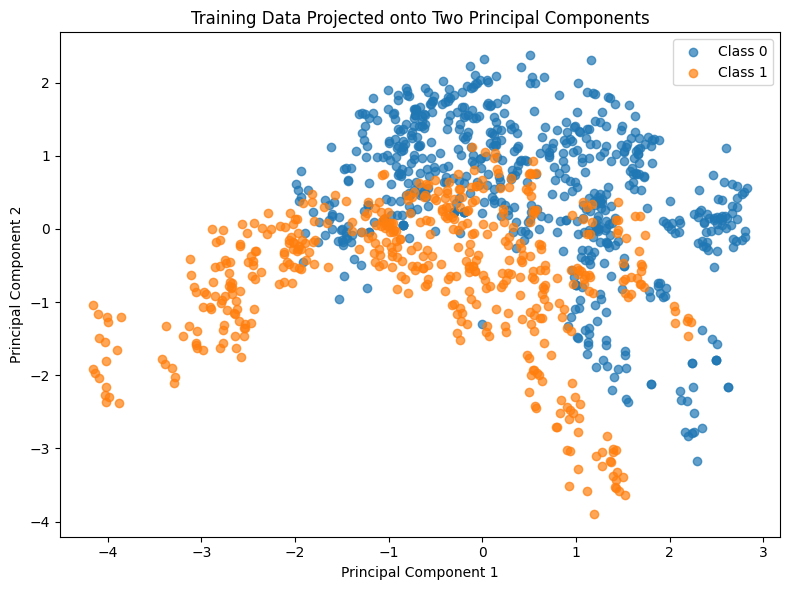

Explained variance: [0.544  0.3248]
4. Implement the perceptron manually
For observation (x_i), the perceptron computes:

[ z_i = w^	op x_i + b ]

The prediction is:

[ \hat{y}_i =
{+1−1zi≥0zi<0
]

When an observation is misclassified:

[ w \leftarrow w + \eta y_i x_i ]

[ b \leftarrow b + \eta y_i ]

where (\eta) is the learning rate.

The implementation below:

shuffles observations during each epoch;
records errors, weights and bias;
stops early if an epoch has zero mistakes;
retains the best observed parameters


In [73]:
pca_for_view = PCA(n_components=2)
X_train_pca = pca_for_view.fit_transform(X_train)

plt.figure(figsize=(8, 6))

for label in (-1, 1):
    mask = y_train == label
    plt.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        label=f"Class {0 if label == -1 else 1}",
        alpha=0.7,
    )

plt.title("Training Data Projected onto Two Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Explained variance:",
    np.round(pca_for_view.explained_variance_ratio_, 4),
)

print("4. Implement the perceptron manually\nFor observation (x_i), the perceptron computes:\n\n[ z_i = w^\top x_i + b ]\n\nThe prediction is:\n\n[ \hat{y}_i =\n{+1−1zi≥0zi<0\n]\n\nWhen an observation is misclassified:\n\n[ w \leftarrow w + \eta y_i x_i ]\n\n[ b \leftarrow b + \eta y_i ]\n\nwhere (\eta) is the learning rate.\n\nThe implementation below:\n\nshuffles observations during each epoch;\nrecords errors, weights and bias;\nstops early if an epoch has zero mistakes;\nretains the best observed parameters")

# ==========================================================
# 16. Manual perceptron implementation
# ==========================================================


In [74]:
class ManualPerceptron:
    def __init__(
        self,
        learning_rate=0.01,
        epochs=100,
        shuffle=True,
        random_state=42,
    ):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.shuffle = shuffle
        self.random_state = random_state

    @staticmethod
    def activation(score):
        return np.where(score >= 0, 1, -1)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)

        if set(np.unique(y)) - {-1, 1}:
            raise ValueError("The perceptron labels must be -1 or +1.")

        rng = np.random.default_rng(self.random_state)

        self.weights_ = np.zeros(X.shape[1], dtype=float)
        self.bias_ = 0.0

        self.errors_per_epoch_ = []
        self.weights_history_ = []
        self.bias_history_ = []

        self.best_errors_ = np.inf
        self.best_weights_ = self.weights_.copy()
        self.best_bias_ = self.bias_
        self.best_epoch_ = 0
        self.converged_ = False

        for epoch in range(self.epochs):
            indices = np.arange(X.shape[0])

            if self.shuffle:
                rng.shuffle(indices)

            errors = 0

            for index in indices:
                sample = X[index]
                target = y[index]

                score = np.dot(sample, self.weights_) + self.bias_
                prediction = 1 if score >= 0 else -1

                if prediction != target:
                    update = self.learning_rate * target
                    self.weights_ += update * sample
                    self.bias_ += update
                    errors += 1

            self.errors_per_epoch_.append(errors)
            self.weights_history_.append(self.weights_.copy())
            self.bias_history_.append(self.bias_)

            if errors < self.best_errors_:
                self.best_errors_ = errors
                self.best_weights_ = self.weights_.copy()
                self.best_bias_ = self.bias_
                self.best_epoch_ = epoch + 1

            if errors == 0:
                self.converged_ = True
                break

        self.weights_history_ = np.asarray(self.weights_history_)
        self.bias_history_ = np.asarray(self.bias_history_)

        return self

    def decision_function(self, X, use_pocket=False):
        X = np.asarray(X, dtype=float)

        if use_pocket:
            weights = self.best_weights_
            bias = self.best_bias_
        else:
            weights = self.weights_
            bias = self.bias_

        return X @ weights + bias

    def predict(self, X, use_pocket=False):
        scores = self.decision_function(X, use_pocket=use_pocket)
        return self.activation(scores)

# ==========================================================
# 17. Train the manual perceptron
# ==========================================================


In [75]:
model = ManualPerceptron(
    learning_rate=0.01,
    epochs=100,
    shuffle=True,
    random_state=RANDOM_STATE,
)

model.fit(X_train, y_train)

print("Epochs completed       :", len(model.errors_per_epoch_))
print("Converged              :", model.converged_)
print("Best training errors   :", model.best_errors_)
print("Best epoch             :", model.best_epoch_)
print("Final weights          :", np.round(model.weights_, 4))
print("Final bias             :", round(model.bias_, 4))
print("Pocket weights         :", np.round(model.best_weights_, 4))
print("Pocket bias            :", round(model.best_bias_, 4))

if not model.converged_:
    print(
        "\nThe training errors did not reach zero. "
        "This is consistent with non-separable or noisy data."
    )
print("5. Training diagnostics\nA perceptron learning curve is not expected to decrease smoothly. One update changes the boundary for every observation, so correcting one mistake can create another.\n\nFor linearly separable data, the classical perceptron converges after a finite number of updates. For non-separable data, it can continue to oscillate.")

Epochs completed       : 100
Converged              : False
Best training errors   : 8
Best epoch             : 22
Final weights          : [-0.2465 -0.2739 -0.245   0.0047]
Final bias             : -0.15
Pocket weights         : [-0.176  -0.1744 -0.1616 -0.0099]
Pocket bias            : -0.09

The training errors did not reach zero. This is consistent with non-separable or noisy data.
5. Training diagnostics
A perceptron learning curve is not expected to decrease smoothly. One update changes the boundary for every observation, so correcting one mistake can create another.

For linearly separable data, the classical perceptron converges after a finite number of updates. For non-separable data, it can continue to oscillate.


# ==========================================================
# 18. Visual 9: Misclassifications per epoch
# ==========================================================


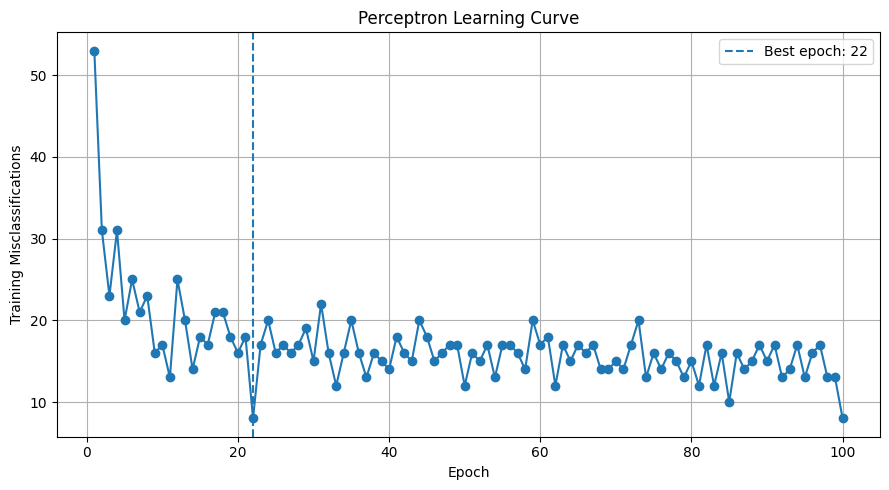

In [76]:
epochs_completed = np.arange(1, len(model.errors_per_epoch_) + 1)

plt.figure(figsize=(9, 5))
plt.plot(
    epochs_completed,
    model.errors_per_epoch_,
    marker="o",
)
plt.axvline(
    model.best_epoch_,
    linestyle="--",
    label=f"Best epoch: {model.best_epoch_}",
)
plt.title("Perceptron Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Training Misclassifications")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================================
# 19. Visual 10: Weight trajectories
# ==========================================================


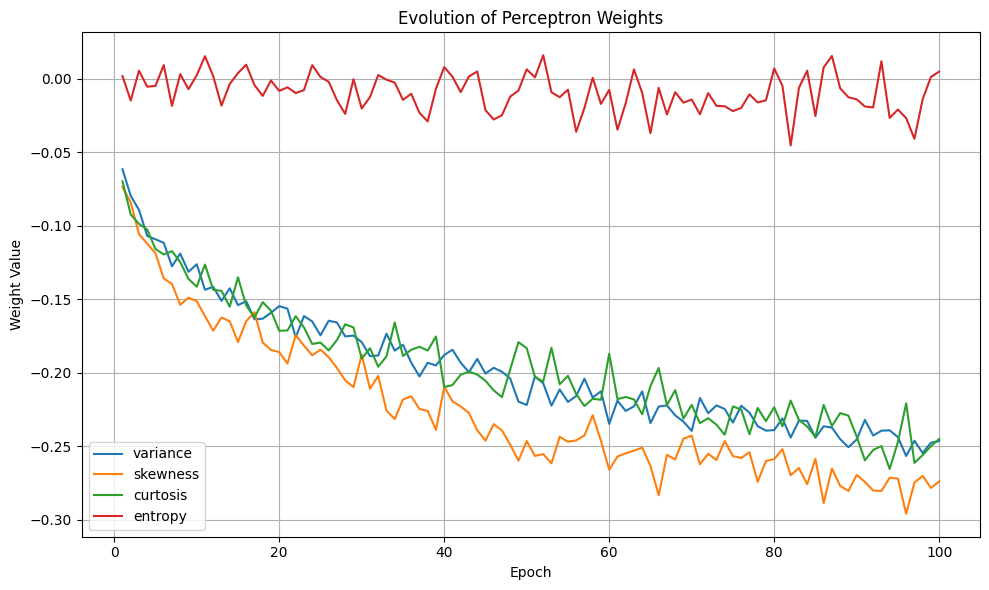

In [77]:
plt.figure(figsize=(10, 6))

for feature_index, feature_name in enumerate(feature_columns):
    plt.plot(
        epochs_completed,
        model.weights_history_[:, feature_index],
        label=feature_name,
    )

plt.title("Evolution of Perceptron Weights")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================================
# 20. Visual 11: Bias trajectory
# ==========================================================


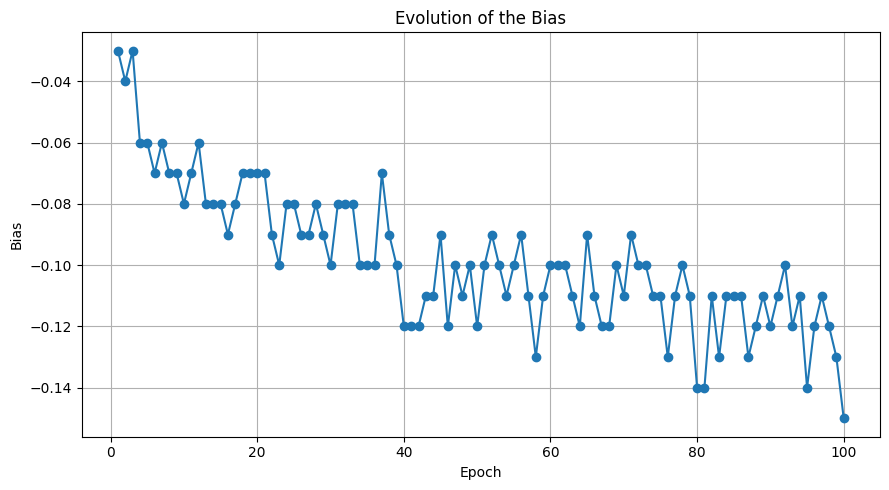

6. Evaluate the four-feature model
The main evaluation below uses the pocket parameters: the parameters from the epoch with the fewest training mistakes.

This is useful when the data are not perfectly linearly separable. The classical final-epoch model is also retained and compared later.


In [78]:
plt.figure(figsize=(9, 5))
plt.plot(
    epochs_completed,
    model.bias_history_,
    marker="o",
)
plt.title("Evolution of the Bias")
plt.xlabel("Epoch")
plt.ylabel("Bias")
plt.grid(True)
plt.tight_layout()
plt.show()

print("6. Evaluate the four-feature model\nThe main evaluation below uses the pocket parameters: the parameters from the epoch with the fewest training mistakes.\n\nThis is useful when the data are not perfectly linearly separable. The classical final-epoch model is also retained and compared later.")

# ==========================================================
# 21. Generate test predictions
# ==========================================================


In [79]:
y_pred_pocket = model.predict(X_test, use_pocket=True)
y_pred_final = model.predict(X_test, use_pocket=False)

print("First 15 test predictions")
prediction_preview = pd.DataFrame({
    "Actual": y_test[:15],
    "Pocket prediction": y_pred_pocket[:15],
    "Final-epoch prediction": y_pred_final[:15],
})

print(prediction_preview.to_string(index=False))

First 15 test predictions
 Actual  Pocket prediction  Final-epoch prediction
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1


# ==========================================================
# 22. Calculate classification metrics
# ==========================================================


In [82]:
def metric_summary(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0,
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0,
        ),
    }

pocket_metrics = metric_summary(y_test, y_pred_pocket)
final_metrics = metric_summary(y_test, y_pred_final)

metrics_table = pd.DataFrame({
    "Pocket model": pocket_metrics,
    "Final-epoch model": final_metrics,
}).T

print(metrics_table.round(4).to_string())

                   Accuracy  Precision  Recall      F1
Pocket model         0.9922        1.0  0.9846  0.9922
Final-epoch model    0.9922        1.0  0.9846  0.9922


# ==========================================================
# 23. Visual 12: Performance metrics
# ==========================================================


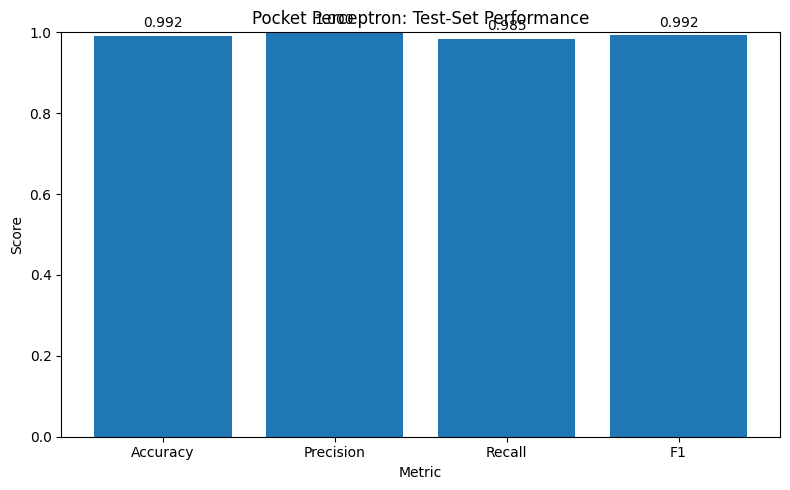

In [83]:
metric_names = list(pocket_metrics.keys())
metric_values = list(pocket_metrics.values())

plt.figure(figsize=(8, 5))
plt.bar(metric_names, metric_values)
plt.ylim(0, 1)
plt.title("Pocket Perceptron: Test-Set Performance")
plt.xlabel("Metric")
plt.ylabel("Score")

for index, value in enumerate(metric_values):
    plt.text(index, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()
plt.show()

# ==========================================================
# 24. Classification report
# ==========================================================


In [84]:
print(
    classification_report(
        y_test,
        y_pred_pocket,
        labels=[-1, 1],
        target_names=["Class 0", "Class 1"],
        zero_division=0,
    )
)

              precision    recall  f1-score   support

     Class 0       0.98      1.00      0.99       125
     Class 1       1.00      0.98      0.99       130

    accuracy                           0.99       255
   macro avg       0.99      0.99      0.99       255
weighted avg       0.99      0.99      0.99       255



# ==========================================================
# 25. Visual 13: Confusion matrix
# ==========================================================


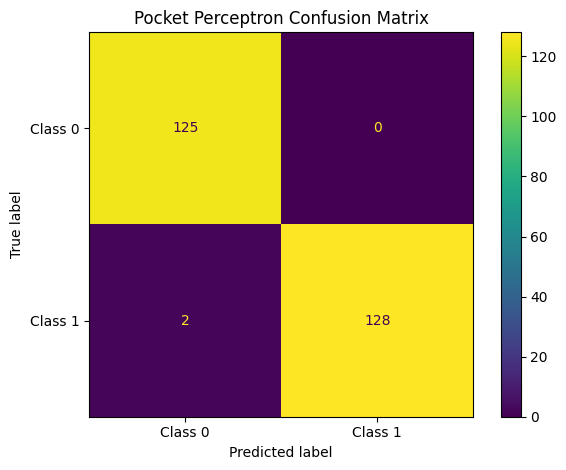

In [85]:
cm = confusion_matrix(
    y_test,
    y_pred_pocket,
    labels=[-1, 1],
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"],
)

display.plot()
plt.title("Pocket Perceptron Confusion Matrix")
plt.tight_layout()
plt.show()

# ==========================================================
# 26. Visual 14: Decision-score distributions
# ==========================================================
# Distance from zero indicates the model's signed confidence,
# but it is not a calibrated probability.

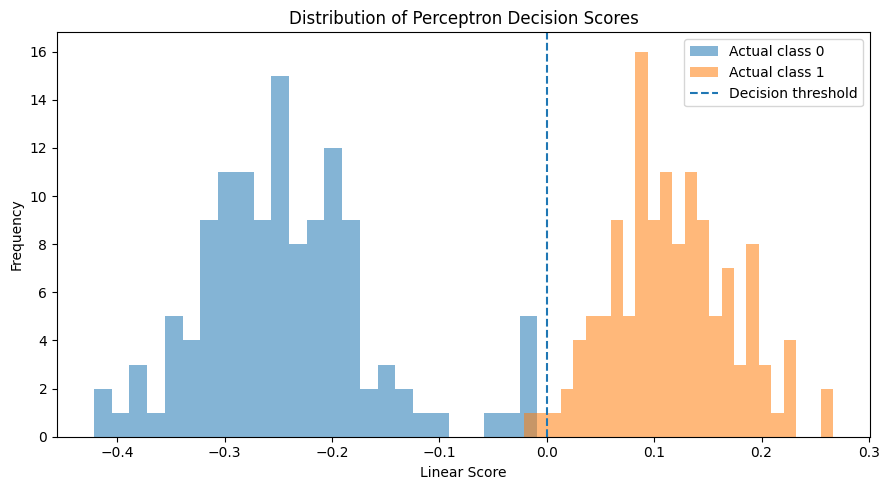

In [86]:
test_scores = model.decision_function(
    X_test,
    use_pocket=True,
)

plt.figure(figsize=(9, 5))

for label in (-1, 1):
    plt.hist(
        test_scores[y_test == label],
        bins=25,
        alpha=0.55,
        label=f"Actual class {0 if label == -1 else 1}",
    )

plt.axvline(0, linestyle="--", label="Decision threshold")
plt.title("Distribution of Perceptron Decision Scores")
plt.xlabel("Linear Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================================
# 27. Inspect misclassified test observations
# ==========================================================


In [87]:
misclassified_mask = y_pred_pocket != y_test
misclassified_indices = np.where(misclassified_mask)[0]

misclassified_table = pd.DataFrame(
    X_test[misclassified_mask],
    columns=[f"Scaled {name}" for name in feature_columns],
)

misclassified_table["Actual"] = y_test[misclassified_mask]
misclassified_table["Predicted"] = y_pred_pocket[misclassified_mask]
misclassified_table["Score"] = test_scores[misclassified_mask]

print("Number of misclassified test observations:", len(misclassified_table))
print(misclassified_table.head(15).round(4).to_string(index=False))

print("7. Geometric decision-boundary visualisation\nThe main perceptron uses four features, so its decision boundary is a hyperplane in four-dimensional feature space.\n\nTo draw a visible two-dimensional boundary, the next section:\n\nprojects the scaled data to two principal components;\ntrains a separate two-feature perceptron;\ndraws its decision regions.\nThis visual model is for geometric interpretation.\nIt is not the same model as the four-feature classifier evaluated above.")

Number of misclassified test observations: 2
 Scaled variance  Scaled skewness  Scaled curtosis  Scaled entropy  Actual  Predicted   Score
         -1.3606          -2.6867           3.8552         -0.4078       1         -1 -0.0008
          0.5376          -0.0321          -1.0181          0.6649       1         -1 -0.0211
7. Geometric decision-boundary visualisation
The main perceptron uses four features, so its decision boundary is a hyperplane in four-dimensional feature space.

To draw a visible two-dimensional boundary, the next section:

projects the scaled data to two principal components;
trains a separate two-feature perceptron;
draws its decision regions.
This visual model is for geometric interpretation.
It is not the same model as the four-feature classifier evaluated above.


# ==========================================================
# 28. Prepare a two-dimensional PCA representation
# ==========================================================


In [88]:
pca_2d = PCA(n_components=2)

X_train_2d = pca_2d.fit_transform(X_train)
X_test_2d = pca_2d.transform(X_test)

visual_model = ManualPerceptron(
    learning_rate=0.01,
    epochs=100,
    shuffle=True,
    random_state=RANDOM_STATE,
)

visual_model.fit(X_train_2d, y_train)

print("2D model converged:", visual_model.converged_)
print("2D best training errors:", visual_model.best_errors_)

2D model converged: False
2D best training errors: 282


# ==========================================================
# 29. Visual 15: Two-dimensional decision regions
# ==========================================================


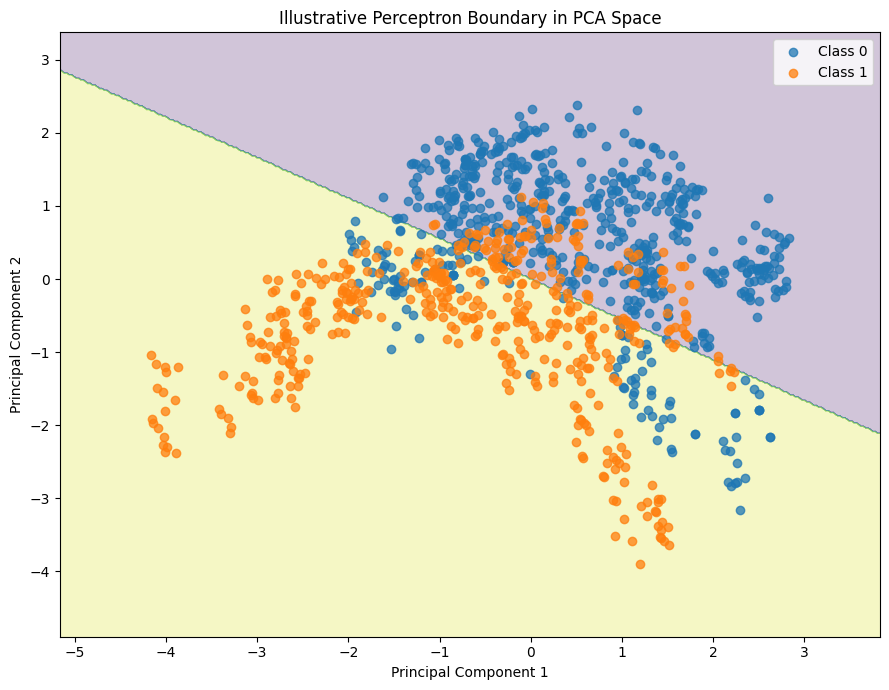

In [89]:
x_min = X_train_2d[:, 0].min() - 1
x_max = X_train_2d[:, 0].max() + 1
y_min = X_train_2d[:, 1].min() - 1
y_max = X_train_2d[:, 1].max() + 1

grid_x, grid_y = np.meshgrid(
    np.linspace(x_min, x_max, 350),
    np.linspace(y_min, y_max, 350),
)

grid_points = np.column_stack([
    grid_x.ravel(),
    grid_y.ravel(),
])

grid_predictions = visual_model.predict(
    grid_points,
    use_pocket=True,
).reshape(grid_x.shape)

plt.figure(figsize=(9, 7))
plt.contourf(
    grid_x,
    grid_y,
    grid_predictions,
    alpha=0.25,
)

for label in (-1, 1):
    mask = y_train == label
    plt.scatter(
        X_train_2d[mask, 0],
        X_train_2d[mask, 1],
        label=f"Class {0 if label == -1 else 1}",
        alpha=0.75,
    )

plt.title("Illustrative Perceptron Boundary in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================================
# 30. Visual 16: Correct and incorrect test predictions in PCA space
# ==========================================================


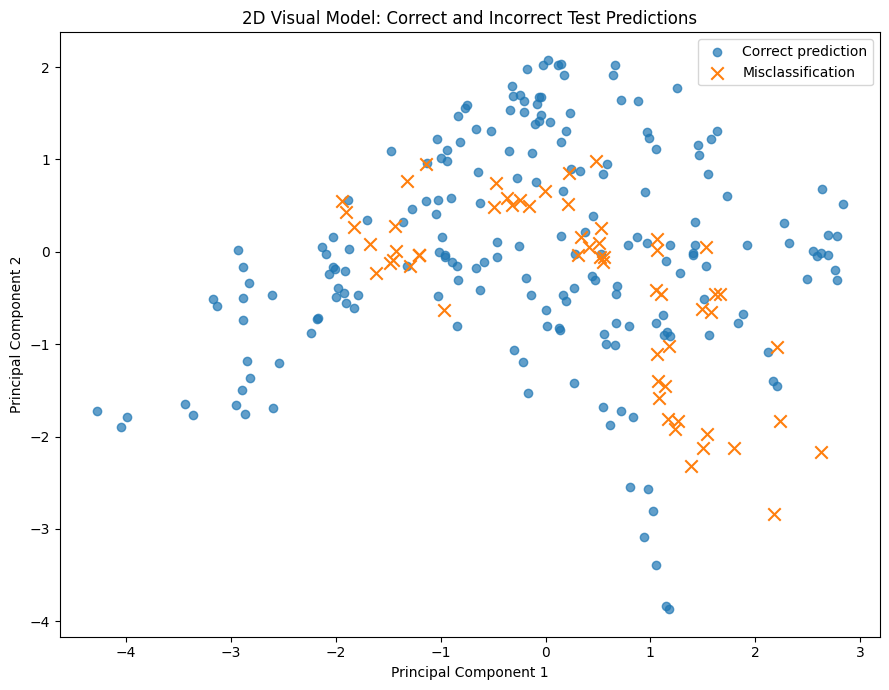

8. Compare with scikit-learn
This comparison is not intended to prove that one implementation is universally superior.

It checks whether the manual implementation behaves plausibly relative to an established library implementation. Differences can arise from:

implementation details;
shuffling;
stopping rules;
intercept handling;
regularisation defaults;
which epoch's parameters are retained.


In [90]:
visual_test_predictions = visual_model.predict(
    X_test_2d,
    use_pocket=True,
)

correct_mask = visual_test_predictions == y_test

plt.figure(figsize=(9, 7))

plt.scatter(
    X_test_2d[correct_mask, 0],
    X_test_2d[correct_mask, 1],
    label="Correct prediction",
    alpha=0.7,
)

plt.scatter(
    X_test_2d[~correct_mask, 0],
    X_test_2d[~correct_mask, 1],
    marker="x",
    s=80,
    label="Misclassification",
)

plt.title("2D Visual Model: Correct and Incorrect Test Predictions")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

print("8. Compare with scikit-learn\nThis comparison is not intended to prove that one implementation is universally superior.\n\nIt checks whether the manual implementation behaves plausibly relative to an established library implementation. Differences can arise from:\n\nimplementation details;\nshuffling;\nstopping rules;\nintercept handling;\nregularisation defaults;\nwhich epoch's parameters are retained.")

# ==========================================================
# 31. Compare with scikit-learn's perceptron
# ==========================================================


In [91]:
sk_model = SklearnPerceptron(
    eta0=0.01,
    max_iter=100,
    tol=None,
    shuffle=True,
    random_state=RANDOM_STATE,
    fit_intercept=True,
)

sk_model.fit(X_train, y_train)
sk_predictions = sk_model.predict(X_test)

comparison = pd.DataFrame({
    "Manual pocket": pocket_metrics,
    "Manual final epoch": final_metrics,
    "scikit-learn": metric_summary(y_test, sk_predictions),
}).T

print(comparison.round(4).to_string())

                    Accuracy  Precision  Recall      F1
Manual pocket         0.9922     1.0000  0.9846  0.9922
Manual final epoch    0.9922     1.0000  0.9846  0.9922
scikit-learn          0.9804     0.9771  0.9846  0.9808


# ==========================================================
# 32. Visual 17: Model comparison
# ==========================================================


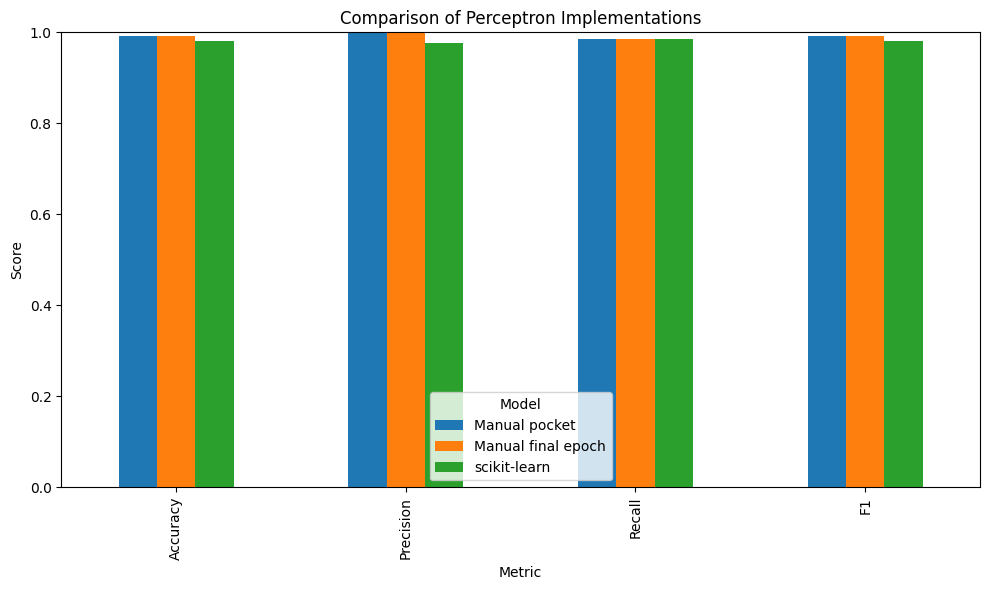

In [92]:
comparison.T.plot(kind="bar", figsize=(10, 6))
plt.ylim(0, 1)
plt.title("Comparison of Perceptron Implementations")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

==========================================================
PERCEPTRON MSc GUIDED LAB COMPLETED
==========================================================
Random seed                 : 42
Training observations       : 1117
Test observations           : 255
Epochs completed            : 100
Classical model converged    : False
Best training error count   : 8
Pocket-model test accuracy  : 0.9922
==========================================================
Colab paid products
-
Cancel contracts here

## Multilayer Perceptron Classifier

A single-layer perceptron can only learn linearly separable patterns. For more complex, non-linear classification tasks, a Multilayer Perceptron (MLP) is used. An MLP is a type of artificial neural network composed of multiple layers of nodes in a directed graph, with each layer fully connected to the next one. It consists of at least three layers: an input layer, one or more hidden layers, and an output layer.

Key characteristics:

*   **Input Layer**: Receives the input features.
*   **Hidden Layers**: Perform non-linear transformations on the inputs. Each neuron in a hidden layer uses an activation function (e.g., ReLU, sigmoid, tanh) to introduce non-linearity, allowing the network to learn complex patterns.
*   **Output Layer**: Produces the final predictions. For binary classification, it typically has one neuron with a sigmoid activation, or two neurons with softmax for multi-class classification.
*   **Backpropagation**: The algorithm used to train MLPs, which involves calculating the gradient of the loss function with respect to each weight and updating the weights to minimize the loss.

### Implement and Train the MLP

In [93]:
from sklearn.neural_network import MLPClassifier

# Initialize and train the MLP Classifier
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100, 50), # Two hidden layers with 100 and 50 neurons respectively
    max_iter=500, # Maximum number of iterations for the solver to converge
    random_state=RANDOM_STATE, # For reproducibility
    activation='relu', # Activation function for the hidden layers
    solver='adam', # The solver for weight optimization
    learning_rate_init=0.001 # Initial learning rate
)

mlp_model.fit(X_train, y_train)

print("MLP Classifier trained successfully.")

MLP Classifier trained successfully.


### Evaluate the MLP Model

In [94]:
mlp_predictions = mlp_model.predict(X_test)

mlp_metrics = metric_summary(y_test, mlp_predictions)

print("MLP Classifier Test Metrics:")
for metric, value in mlp_metrics.items():
    print(f"{metric}: {value:.4f}")

MLP Classifier Test Metrics:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1: 1.0000


### Compare MLP with Perceptron Implementations

                         Accuracy  Precision  Recall      F1
Manual pocket              0.9922     1.0000  0.9846  0.9922
Manual final epoch         0.9922     1.0000  0.9846  0.9922
scikit-learn Perceptron    0.9804     0.9771  0.9846  0.9808
scikit-learn MLP           1.0000     1.0000  1.0000  1.0000


<Figure size 1200x700 with 0 Axes>

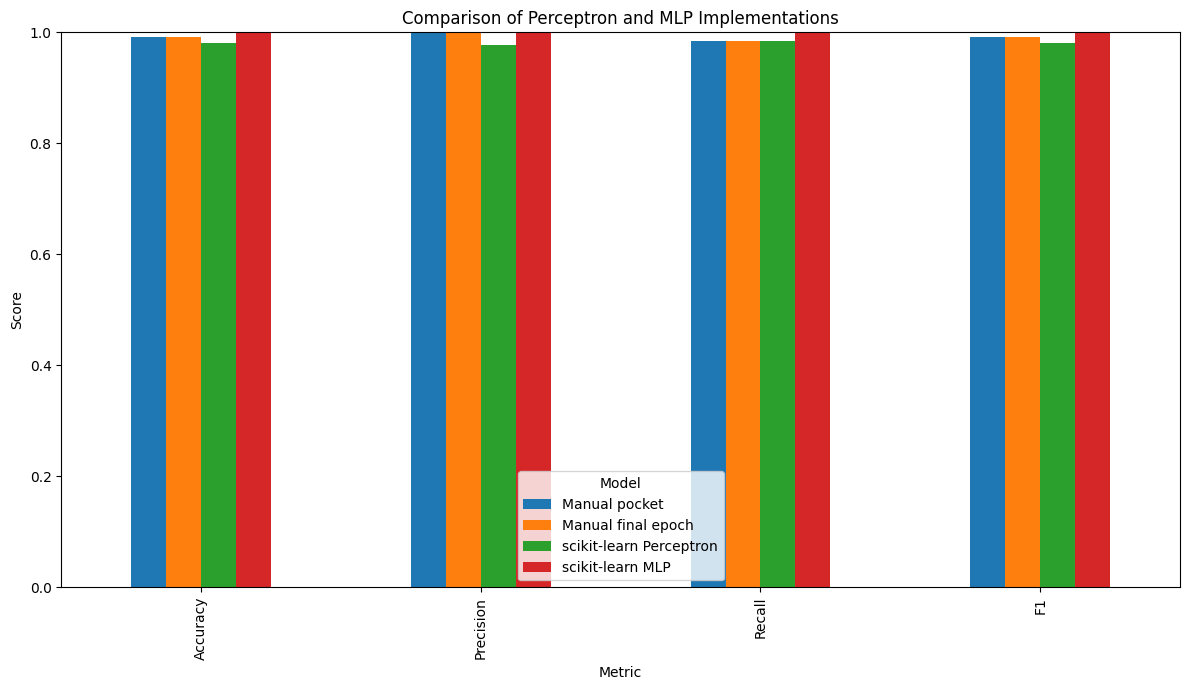

In [96]:
comparison_with_mlp = pd.DataFrame({
    "Manual pocket": pocket_metrics,
    "Manual final epoch": final_metrics,
    "scikit-learn Perceptron": metric_summary(y_test, sk_predictions),
    "scikit-learn MLP": mlp_metrics
}).T

print(comparison_with_mlp.round(4).to_string())

# Visualize the comparison
plt.figure(figsize=(12, 7))
comparison_with_mlp.T.plot(kind="bar", figsize=(12, 7))
plt.ylim(0, 1)
plt.title("Comparison of Perceptron and MLP Implementations")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(title="Model")
plt.tight_layout()
plt.show()